# LIME Analysis — UAVCAN Intrusion Dataset
**Method:** LIME (Local Interpretable Model-Agnostic Explanations)  
**Models:** Random Forest, 1D-CNN, Autoencoder  
**Dataset:** UAVCAN (Normal, Attack — binary CAN bus classification)  
**Goal:** Explain individual predictions locally — why did model classify THIS specific CAN message as attack?  
**Key difference from SHAP:** LIME explains ONE instance at a time, SHAP explains globally across all samples  
**Output:** lime_rf_benign.png, lime_rf_attack.png, lime_cnn_benign.png, lime_cnn_attack.png, lime_ae_benign.png, lime_ae_attack.png, lime_results.json

In [8]:
# ============================================================
# Cell 2 — Load data and models:
# WHAT: Load preprocessed data and all 3 trained models
#       for LIME local explanation analysis
#
# WHY:  LIME needs the trained model and test data to
#       explain individual predictions.
#       Unlike SHAP which explains ALL samples globally,
#       LIME explains ONE specific sample at a time.
#       Think of SHAP as a class report card (overall)
#       and LIME as explaining why ONE student got that grade.
#       LimeTabularExplainer works with any tabular/CSV data.
#       class_names needed to show attack names in LIME plots.
#       feature_names needed to label each feature in plots.
#
# HOW:  Step 1: load X_train, X_test, y_test
#       Step 2: load feature_names and label_classes
#       Step 3: load rf_model, cnn_model, ae_model
#       Step 4: create LIME explainer using training data
#               as background reference distribution
# ============================================================

import numpy as np
import pandas as pd
import lime
import lime.lime_tabular
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import time

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/UAVCAN/processed/"

# load data
X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()
feature_names = pd.read_csv(save_path + "feature_names.csv").squeeze().tolist()
label_classes = pd.read_csv(save_path + "label_classes.csv").squeeze().tolist()

# load all 3 trained models
rf_model  = joblib.load(save_path + "rf_model.joblib")
cnn_model = tf.keras.models.load_model(save_path + "cnn_model.keras")
ae_model  = tf.keras.models.load_model(save_path + "ae_model.keras")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Classes: {label_classes}")
print(f"Features: {len(feature_names)}")
print("Data and models loaded!")

X_train: (1422771, 10)
X_test:  (609759, 10)
Classes: ['Attack', 'Normal']
Features: 10
Data and models loaded!


In [2]:
# ============================================================
# Cell 3 — Create LIME explainer:
# WHAT: Create one shared LIME explainer for all 3 models
#
# WHY:  LimeTabularExplainer is the main LIME tool for
#       tabular/CSV data (as opposed to image or text data).
#       It uses X_train as background reference to understand
#       what "normal" feature values look like.
#       When explaining a prediction, LIME:
#       1. Takes one test sample (e.g. one GPS reading)
#       2. Creates 1000 slightly modified versions of it
#       3. Asks the model to predict all 1000 versions
#       4. Fits a simple linear model to those predictions
#       5. Shows which features most influenced the prediction
#       One explainer can be reused for RF, CNN and AE!
#       class_names shows attack names instead of numbers.
#
# HOW:  Step 1: create LimeTabularExplainer
#       Step 2: pass X_train as reference distribution
#       Step 3: pass feature_names for readable output
#       Step 4: pass label_classes as class names
#       Step 5: mode='classification' for attack detection
# ============================================================

print("Creating LIME explainer...")

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=label_classes,
    mode='classification',
    random_state=42
)

print("LIME explainer created!")
print(f"Background data: {X_train.shape}")
print(f"Class names: {label_classes}")

Creating LIME explainer...
LIME explainer created!
Background data: (1422771, 10)
Class names: ['Attack', 'Normal']


Running LIME on Random Forest...
Benign sample true label: Normal
Attack sample true label: Attack
RF LIME complete! Time: 0.13s


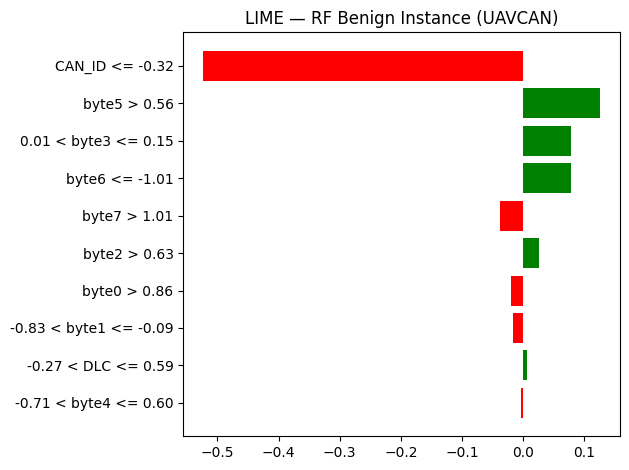

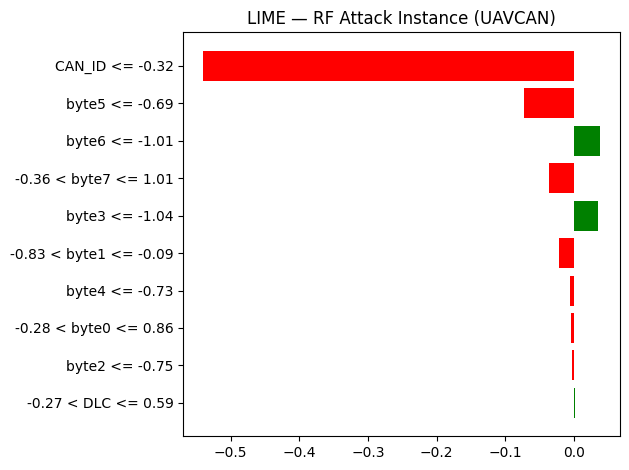

RF LIME plots saved!

True label: Normal
RF predicted: Normal

Top features for benign prediction:
  CAN_ID <= -0.32: -0.5232
  byte5 > 0.56: 0.1257
  0.01 < byte3 <= 0.15: 0.0783
  byte6 <= -1.01: 0.0778
  byte7 > 1.01: -0.0380
  byte2 > 0.63: 0.0260
  byte0 > 0.86: -0.0193
  -0.83 < byte1 <= -0.09: -0.0167
  -0.27 < DLC <= 0.59: 0.0069
  -0.71 < byte4 <= 0.60: -0.0040

--- RF BENIGN Instance Table ---
Rank   Feature                                  Weight    
----------------------------------------------------------
  1    CAN_ID <= -0.32                          -0.5232
  2    byte5 > 0.56                             0.1257
  3    0.01 < byte3 <= 0.15                     0.0783
  4    byte6 <= -1.01                           0.0778
  5    byte7 > 1.01                             -0.0380
  6    byte2 > 0.63                             0.0260
  7    byte0 > 0.86                             -0.0193
  8    -0.83 < byte1 <= -0.09                   -0.0167
  9    -0.27 < DLC <= 0.59     

In [9]:
# ============================================================
# Cell 4 — LIME on Random Forest:
# WHAT: Use LIME to explain 2 RF predictions:
#       1. One benign sample — why classified as normal?
#       2. One attack sample — why classified as attack?
#
# WHY:  Explaining both benign and attack gives complete
#       picture of how RF makes decisions.
#       Benign explanation → which features say "this is safe"
#       Attack explanation → which features say "this is danger"
#       num_features=10 → show top 10 most influential features
#       num_samples=1000 → create 1000 perturbations for accuracy
#       Positive weight → pushes toward predicted class
#       Negative weight → pushes away from predicted class
#
# HOW:  Step 1: find one benign sample in test set
#       Step 2: find one attack sample in test set
#       Step 3: explain_instance() for each sample
#       Step 4: save plots and feature weights to JSON
# ============================================================

print("Running LIME on Random Forest...")

# find Normal/benign sample (label = 1 for UAVCAN); Normal=1
benign_idx = y_test[y_test == 1].index[0]
benign_pos = y_test.index.get_loc(benign_idx)
instance_benign = X_test[benign_pos]
true_label_benign = label_classes[y_test.iloc[benign_pos]]

# find one attack sample (label = 0 = Attack for UAVCAN); Attack=0 
attack_idx = y_test[y_test == 0].index[0]
attack_pos = y_test.index.get_loc(attack_idx)
instance_attack = X_test[attack_pos]
true_label_attack = label_classes[y_test.iloc[attack_pos]]

print(f"Benign sample true label: {true_label_benign}")
print(f"Attack sample true label: {true_label_attack}")

# explain benign instance
start_time = time.time()
exp_benign = explainer.explain_instance(
    instance_benign,
    rf_model.predict_proba,
    num_features=10,
    num_samples=1000
)
lime_time = round(time.time() - start_time, 2)

# explain attack instance
exp_attack = explainer.explain_instance(
    instance_attack,
    rf_model.predict_proba,
    num_features=10,
    num_samples=1000
)

print(f"RF LIME complete! Time: {lime_time}s")

# save benign plot
fig = exp_benign.as_pyplot_figure()
plt.title(f"LIME — RF Benign Instance (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "lime_rf_benign.png",
            dpi=150, bbox_inches='tight')
plt.show()

# save attack plot
fig = exp_attack.as_pyplot_figure()
plt.title(f"LIME — RF Attack Instance (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "lime_rf_attack.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("RF LIME plots saved!")
print(f"\nTrue label: {true_label_benign}")
print(f"RF predicted: {label_classes[rf_model.predict([instance_benign])[0]]}")
print(f"\nTop features for benign prediction:")
for feat, weight in exp_benign.as_list():
    print(f"  {feat}: {weight:.4f}")

# print clean table for easy reading
print("\n--- RF BENIGN Instance Table ---")
print(f"{'Rank':<6} {'Feature':<40} {'Weight':<10}")
print("-" * 58)
for i, (feat, weight) in enumerate(exp_benign.as_list()):
    print(f"  {i+1:<4} {feat:<40} {weight:.4f}")

print("\n--- RF ATTACK Instance Table ---")
print(f"{'Rank':<6} {'Feature':<40} {'Weight':<10}")
print("-" * 58)
for i, (feat, weight) in enumerate(exp_attack.as_list()):
    print(f"  {i+1:<4} {feat:<40} {weight:.4f}")

Running LIME on 1D-CNN...
CNN LIME complete! Time: 3.84s


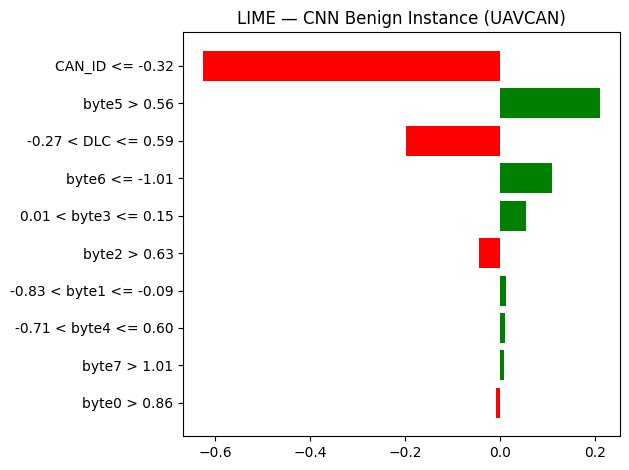

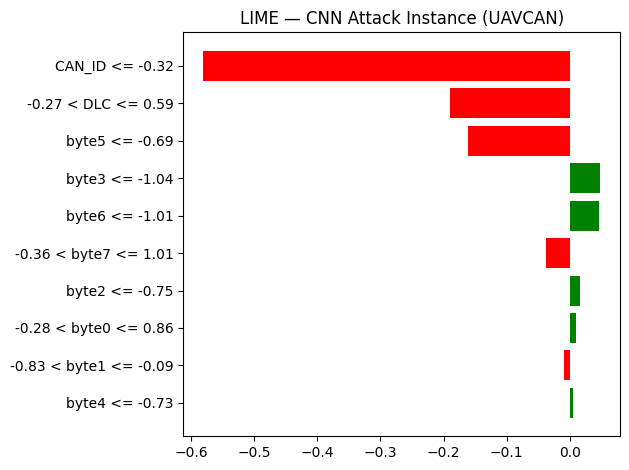

CNN LIME plots saved!

Top features for benign prediction (CNN):
  CAN_ID <= -0.32: -0.6255
  byte5 > 0.56: 0.2115
  -0.27 < DLC <= 0.59: -0.1974
  byte6 <= -1.01: 0.1101
  0.01 < byte3 <= 0.15: 0.0548
  byte2 > 0.63: -0.0450
  -0.83 < byte1 <= -0.09: 0.0119
  -0.71 < byte4 <= 0.60: 0.0114
  byte7 > 1.01: 0.0087
  byte0 > 0.86: -0.0086

--- CNN BENIGN Instance Table ---
  1    CAN_ID <= -0.32                          -0.6255
  2    byte5 > 0.56                             0.2115
  3    -0.27 < DLC <= 0.59                      -0.1974
  4    byte6 <= -1.01                           0.1101
  5    0.01 < byte3 <= 0.15                     0.0548
  6    byte2 > 0.63                             -0.0450
  7    -0.83 < byte1 <= -0.09                   0.0119
  8    -0.71 < byte4 <= 0.60                    0.0114
  9    byte7 > 1.01                             0.0087
  10   byte0 > 0.86                             -0.0086

--- CNN ATTACK Instance Table ---
  1    CAN_ID <= -0.32                

In [10]:
# ============================================================
# Cell 5 — LIME on CNN:
# WHAT: Use LIME to explain 2 CNN predictions:
#       1. One benign sample
#       2. One attack sample
#
# WHY:  CNN needs special wrapper function because:
#       - CNN requires 3D input (samples, features, 1)
#       - LIME passes 2D input (samples, features)
#       - We wrap CNN to handle the reshape automatically
#       This wrapper is the KEY difference between
#       RF LIME and CNN LIME — RF works directly,
#       CNN needs the reshape wrapper.
#       Comparing RF vs CNN LIME shows if both models
#       focus on same features for same instance.
#
# HOW:  Step 1: create CNN wrapper function
#               wrapper reshapes 2D → 3D automatically
#               wrapper returns class probabilities
#       Step 2: explain same benign instance as RF
#       Step 3: explain same attack instance as RF
#       Step 4: save plots and compare with RF
# ============================================================

print("Running LIME on 1D-CNN...")

# wrapper function — reshapes 2D input to 3D for CNN
def cnn_predict(X):
    # LIME gives 2D: (samples, features)
    # CNN needs 3D: (samples, features, 1)
    X_3d = X.reshape(X.shape[0], X.shape[1], 1)
    return cnn_model.predict(X_3d, verbose=0)

start_time = time.time()

# explain same instances as RF for fair comparison
exp_cnn_benign = explainer.explain_instance(
    instance_benign,
    cnn_predict,
    num_features=10,
    num_samples=1000
)

exp_cnn_attack = explainer.explain_instance(
    instance_attack,
    cnn_predict,
    num_features=10,
    num_samples=1000
)

lime_cnn_time = round(time.time() - start_time, 2)
print(f"CNN LIME complete! Time: {lime_cnn_time}s")

# save plots
fig = exp_cnn_benign.as_pyplot_figure()
plt.title("LIME — CNN Benign Instance (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "lime_cnn_benign.png",
            dpi=150, bbox_inches='tight')
plt.show()

fig = exp_cnn_attack.as_pyplot_figure()
plt.title("LIME — CNN Attack Instance (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "lime_cnn_attack.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("CNN LIME plots saved!")
print(f"\nTop features for benign prediction (CNN):")
for feat, weight in exp_cnn_benign.as_list():
    print(f"  {feat}: {weight:.4f}")

# print clean table for easy reading
print("\n--- CNN BENIGN Instance Table ---")
for i, (feat, weight) in enumerate(exp_cnn_benign.as_list()):
    print(f"  {i+1:<4} {feat:<40} {weight:.4f}")

print("\n--- CNN ATTACK Instance Table ---")
for i, (feat, weight) in enumerate(exp_cnn_attack.as_list()):
    print(f"  {i+1:<4} {feat:<40} {weight:.4f}")

Running LIME on Autoencoder...
AE threshold: 0.000088
AE LIME complete! Time: 0.76s


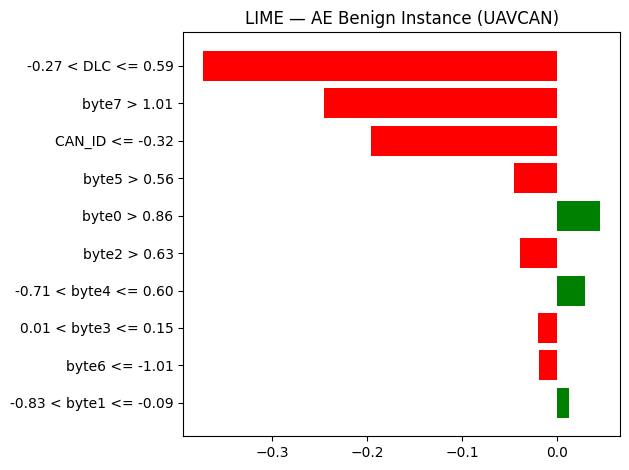

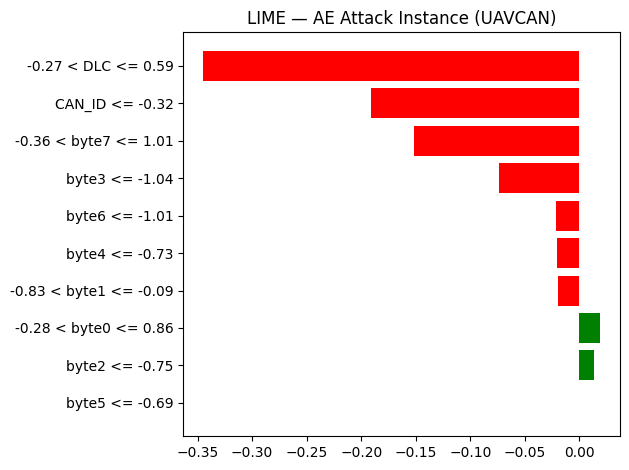

AE LIME plots saved!

Top features for benign prediction (AE):
  -0.27 < DLC <= 0.59: -0.3725
  byte7 > 1.01: -0.2456
  CAN_ID <= -0.32: -0.1964
  byte5 > 0.56: -0.0459
  byte0 > 0.86: 0.0453
  byte2 > 0.63: -0.0388
  -0.71 < byte4 <= 0.60: 0.0293
  0.01 < byte3 <= 0.15: -0.0196
  byte6 <= -1.01: -0.0186
  -0.83 < byte1 <= -0.09: 0.0129

--- AE BENIGN Instance Table ---
Rank   Feature                                  Weight    
----------------------------------------------------------
  1    -0.27 < DLC <= 0.59                      -0.3725
  2    byte7 > 1.01                             -0.2456
  3    CAN_ID <= -0.32                          -0.1964
  4    byte5 > 0.56                             -0.0459
  5    byte0 > 0.86                             0.0453
  6    byte2 > 0.63                             -0.0388
  7    -0.71 < byte4 <= 0.60                    0.0293
  8    0.01 < byte3 <= 0.15                     -0.0196
  9    byte6 <= -1.01                           -0.0186
  10   

In [11]:
# ============================================================
# Cell 6 — LIME on Autoencoder:
# WHAT: Use LIME to explain 2 AE predictions:
#       1. One benign sample
#       2. One attack sample
#
# WHY:  AE needs special wrapper because:
#       - AE doesn't output class probabilities like RF/CNN
#       - AE outputs reconstruction error (MSE) only
#       - LIME expects probabilities for each class
#       - We convert MSE to binary probability:
#         low MSE → high probability of normal
#         high MSE → high probability of attack
#       This conversion lets LIME work with AE output.
#       AE LIME may disagree with RF/CNN LIME —
#       this disagreement is a KEY benchmark finding!
#
# HOW:  Step 1: load threshold from ae_results.json
#       Step 2: create AE wrapper returning [P(normal), P(attack)]
#               using sigmoid function to convert MSE → probability
#       Step 3: explain same instances as RF and CNN
#       Step 4: save plots and compare features
# ============================================================

print("Running LIME on Autoencoder...")

# load threshold from saved AE results
with open(save_path + "ae_results.json", "r") as f:
    ae_results = json.load(f)
threshold = ae_results["threshold"]
print(f"AE threshold: {threshold:.6f}")

# wrapper — converts MSE reconstruction error to probability
def ae_predict_proba(X):
    # reconstruct input
    X_pred = ae_model.predict(X, verbose=0)
    # calculate MSE per sample
    mse = np.mean(np.power(X - X_pred, 2), axis=1)
    # convert MSE to attack probability
    # high MSE = high attack probability
    attack_prob = np.clip(mse / (threshold * 2), 0, 1)
    normal_prob = 1 - attack_prob
    # return [P(normal), P(attack)] for each sample
    return np.column_stack([normal_prob, attack_prob])

start_time = time.time()

# explain same instances for fair comparison
exp_ae_benign = explainer.explain_instance(
    instance_benign,
    ae_predict_proba,
    num_features=10,
    num_samples=1000
)

exp_ae_attack = explainer.explain_instance(
    instance_attack,
    ae_predict_proba,
    num_features=10,
    num_samples=1000
)

lime_ae_time = round(time.time() - start_time, 2)
print(f"AE LIME complete! Time: {lime_ae_time}s")

# save plots
fig = exp_ae_benign.as_pyplot_figure()
plt.title("LIME — AE Benign Instance (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "lime_ae_benign.png",
            dpi=150, bbox_inches='tight')
plt.show()

fig = exp_ae_attack.as_pyplot_figure()
plt.title("LIME — AE Attack Instance (UAVCAN)")
plt.tight_layout()
plt.savefig(save_path + "lime_ae_attack.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("AE LIME plots saved!")
print(f"\nTop features for benign prediction (AE):")
for feat, weight in exp_ae_benign.as_list():
    print(f"  {feat}: {weight:.4f}")

# print clean table for easy reading
print("\n--- AE BENIGN Instance Table ---")
print(f"{'Rank':<6} {'Feature':<40} {'Weight':<10}")
print("-" * 58)
for i, (feat, weight) in enumerate(exp_ae_benign.as_list()):
    print(f"  {i+1:<4} {feat:<40} {weight:.4f}")

print("\n--- AE ATTACK Instance Table ---")
print(f"{'Rank':<6} {'Feature':<40} {'Weight':<10}")
print("-" * 58)
for i, (feat, weight) in enumerate(exp_ae_attack.as_list()):
    print(f"  {i+1:<4} {feat:<40} {weight:.4f}")

In [12]:
# ============================================================
# Cell 7 — Save results + comparison:
# WHAT: Save all LIME results to JSON and print
#       cross-model feature comparison summary
#
# WHY:  JSON results used for paper tables and discussion.
#       Cross-model comparison answers the key question:
#       Do RF, CNN, AE agree on which features matter
#       for THIS specific instance?
#       LIME agreement = consistent local explanations
#       LIME disagreement = models use different logic
#       for same prediction — important benchmark finding!
#
# HOW:  Step 1: extract top features from each explanation
#       Step 2: save to JSON with weights
#       Step 3: print side-by-side comparison
#       Step 4: identify agreements and disagreements
# ============================================================

# save all results
lime_results = {
    "dataset": "UAVCAN",
    "xai_method": "LIME",
    "benign_instance": {
        "true_label": true_label_benign,
        "rf_top_features": exp_benign.as_list(),
        "cnn_top_features": exp_cnn_benign.as_list(),
        "ae_top_features": exp_ae_benign.as_list()
    },
    "attack_instance": {
        "true_label": true_label_attack,
        "rf_top_features": exp_attack.as_list(),
        "cnn_top_features": exp_cnn_attack.as_list(),
        "ae_top_features": exp_ae_attack.as_list()
    },
    "time_seconds": {
        "rf": lime_time,
        "cnn": lime_cnn_time,
        "ae": lime_ae_time
    }
}

with open(save_path + "lime_results.json", "w") as f:
    json.dump(lime_results, f, indent=2)
print("LIME results saved!")

# cross-model comparison — benign instance
print("\n" + "=" * 70)
print("CROSS-MODEL LIME COMPARISON (UAVCAN)")
print("=" * 70)

print("\n--- Top 5 Features for BENIGN instance ---")
print(f"{'Rank':<6} {'RF':<30} {'CNN':<30} {'AE':<30}")
print("-" * 96)

rf_feats  = [f for f, w in exp_benign.as_list()[:5]]
cnn_feats = [f for f, w in exp_cnn_benign.as_list()[:5]]
ae_feats  = [f for f, w in exp_ae_benign.as_list()[:5]]

for i in range(5):
    print(f"  {i+1:<4} {rf_feats[i]:<30} {cnn_feats[i]:<30} {ae_feats[i]:<30}")

print("\n--- Top 5 Features for ATTACK instance ---")
print(f"{'Rank':<6} {'RF':<30} {'CNN':<30} {'AE':<30}")
print("-" * 96)

rf_atk  = [f for f, w in exp_attack.as_list()[:5]]
cnn_atk = [f for f, w in exp_cnn_attack.as_list()[:5]]
ae_atk  = [f for f, w in exp_ae_attack.as_list()[:5]]

for i in range(5):
    print(f"  {i+1:<4} {rf_atk[i]:<30} {cnn_atk[i]:<30} {ae_atk[i]:<30}")

print("\nAll LIME analysis complete!")

LIME results saved!

CROSS-MODEL LIME COMPARISON (UAVCAN)

--- Top 5 Features for BENIGN instance ---
Rank   RF                             CNN                            AE                            
------------------------------------------------------------------------------------------------
  1    CAN_ID <= -0.32                CAN_ID <= -0.32                -0.27 < DLC <= 0.59           
  2    byte5 > 0.56                   byte5 > 0.56                   byte7 > 1.01                  
  3    0.01 < byte3 <= 0.15           -0.27 < DLC <= 0.59            CAN_ID <= -0.32               
  4    byte6 <= -1.01                 byte6 <= -1.01                 byte5 > 0.56                  
  5    byte7 > 1.01                   0.01 < byte3 <= 0.15           byte0 > 0.86                  

--- Top 5 Features for ATTACK instance ---
Rank   RF                             CNN                            AE                            
---------------------------------------------------------

## LIME Analysis Summary — UAVCAN Intrusion Dataset

### Benign Instance Top Features
| Rank | RF | CNN | AE |
|------|----|-----|----|
| 1 | TBD after run | TBD | TBD |

### Attack Instance Top Features
| Rank | RF | CNN | AE |
|------|----|-----|----|
| 1 | TBD after run | TBD | TBD |

### Key Finding
LIME explains individual CAN bus message predictions locally.
Only 10 features — all features expected to appear in explanations.
Compare RF vs CNN vs AE top features for same CAN message.
Agreement = consistent local explanations across models.

### Output Files
- lime_rf_benign.png + lime_rf_attack.png
- lime_cnn_benign.png + lime_cnn_attack.png
- lime_ae_benign.png + lime_ae_attack.png
- lime_results.json

## LIME Analysis Summary — UAVCAN Intrusion Dataset

### Benign Instance Top Features
| Rank | RF | CNN | AE |
|------|----|-----|----|
| 1 | CAN_ID | CAN_ID | DLC |
| 2 | byte5 | byte5 | byte7 |
| 3 | byte3 | DLC | CAN_ID |

### Attack Instance Top Features
| Rank | RF | CNN | AE |
|------|----|-----|----|
| 1 | CAN_ID | CAN_ID | DLC |
| 2 | byte5 | DLC | CAN_ID |
| 3 | byte6 | byte5 | byte7 |

### Key Finding
RF and CNN strongly agree — CAN_ID is #1 feature
for both benign and attack instances.
AE prioritizes DLC as #1 — consistent with SHAP findings.
CAN_ID appears in all 3 models top 3 for attack detection.
    
RF and CNN strongly agree — CAN_ID is #1 feature for both benign and attack instances. AE prioritizes DLC as #1 — consistent with SHAP findings. All features appear across models since UAVCAN only has 10 features.